# AIRMLP7-1500

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from keras.models import Sequential, load_model
from keras.layers import Input, Dense, BatchNormalization
from keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

plt.rcParams.update({'font.size': 14})

In [2]:
def createWindows(df, windowSize):

    # Separando as features e o target
    X = df.drop(columns=['valid_at', 'valore_originale', 'pm2p5_y']).values
    y = df['pm2p5_y'].values

    X_sep = []
    y_sep = []

    # 2. Deslizando a janela
    # O "+ 1" garante que a gente pegue a última janela possível no final do dataset
    for i in range(len(X) - windowSize + 1):
        
        # Pega o bloco de 20 linhas e já "amassa" (flatten) para virar um vetor de 120 colunas
        janela_features = X[i : i + windowSize].flatten()
        X_sep.append(janela_features)
        
        # O Alvo (y) é sempre o valor do PM2.5 referente à ÚLTIMA hora dessa janela.
        # O índice da última hora da janela é (i + windowSize - 1)
        alvo = y[i + windowSize - 1]
        y_sep.append(alvo)

    # 3. Convertendo as listas finais para Arrays do NumPy (O formato que a IA gosta)
    X_final = pd.DataFrame(np.array(X_sep))
    y_final = pd.DataFrame(np.array(y_sep))

    return X_final, y_final

In [3]:
totalFeatures = 6
windowSize    = 20
num_hidden    = 1500

## DADOS + PREPROCESSAMENTO

In [4]:
# Carregando os dados
ari_Mar_01 = pd.read_csv('Dados/ari-1727.csv')[::-1].reset_index(drop=True)
ari_Mar_02 = pd.read_csv('Dados/ari-1952.csv')[::-1].reset_index(drop=True)
ari_Mar_03 = pd.read_csv('Dados/ari-1953.csv')[::-1].reset_index(drop=True)
ari_Oct_01 = pd.read_csv('Dados/ari-1885.csv')[::-1].reset_index(drop=True)
ari_Oct_02 = pd.read_csv('Dados/ari-2049.csv')[::-1].reset_index(drop=True)
rf_01      = pd.read_csv('Dados/rf_1.csv')
rf_02      = pd.read_csv('Dados/rf_2.csv')

# Removendo as linhas com valores ausentes
ari_Mar_01.dropna(inplace=True)
ari_Mar_02.dropna(inplace=True)
ari_Mar_03.dropna(inplace=True)
ari_Oct_01.dropna(inplace=True)
ari_Oct_02.dropna(inplace=True)
rf_01     .dropna(inplace=True)
rf_02     .dropna(inplace=True)

# Convertendo a coluna 'valid_at' para o formato datetime
ari_Mar_01['valid_at'] = pd.to_datetime(ari_Mar_01['valid_at'])
ari_Mar_02['valid_at'] = pd.to_datetime(ari_Mar_02['valid_at'])
ari_Mar_03['valid_at'] = pd.to_datetime(ari_Mar_03['valid_at'])
ari_Oct_01['valid_at'] = pd.to_datetime(ari_Oct_01['valid_at'])
ari_Oct_02['valid_at'] = pd.to_datetime(ari_Oct_02['valid_at'])
rf_01     ['valid_at'] = pd.to_datetime(     rf_01['valid_at'])
rf_02     ['valid_at'] = pd.to_datetime(     rf_02['valid_at'])

# Ajustando o horario para o mesmo fuso GMT-0
rf_01['valid_at'] = rf_01['valid_at'] - pd.Timedelta(hours=1)
rf_02['valid_at'] = rf_02['valid_at'] - pd.Timedelta(hours=1)

# Arredondando os horários para o mais próximo possível
ari_Mar_01["valid_at"] = ari_Mar_01["valid_at"].dt.round("h")
ari_Mar_02["valid_at"] = ari_Mar_02["valid_at"].dt.round("h")
ari_Mar_03["valid_at"] = ari_Mar_03["valid_at"].dt.round("h")
ari_Oct_01["valid_at"] = ari_Oct_01["valid_at"].dt.round("h")
ari_Oct_02["valid_at"] = ari_Oct_02["valid_at"].dt.round("h")
rf_01     ["valid_at"] = rf_01     ["valid_at"].dt.round("h")
rf_02     ["valid_at"] = rf_02     ["valid_at"].dt.round("h")

# Realizando o merge dos DataFrames com base na coluna 'valid_at'
Data_Mar_01 = pd.merge(ari_Mar_01, rf_01, on='valid_at', how='inner')
Data_Mar_02 = pd.merge(ari_Mar_02, rf_01, on='valid_at', how='inner')
Data_Mar_03 = pd.merge(ari_Mar_03, rf_01, on='valid_at', how='inner')
Data_Oct_01 = pd.merge(ari_Oct_01, rf_02, on='valid_at', how='inner')
Data_Oct_02 = pd.merge(ari_Oct_02, rf_02, on='valid_at', how='inner')

# Criando as janelas de dados para cada DataFrame
X_Mar_01, y_Mar_01 = createWindows(Data_Mar_01, windowSize)
X_Mar_02, y_Mar_02 = createWindows(Data_Mar_02, windowSize)
X_Mar_03, y_Mar_03 = createWindows(Data_Mar_03, windowSize)
X_Oct_01, y_Oct_01 = createWindows(Data_Oct_01, windowSize)
X_Oct_02, y_Oct_02 = createWindows(Data_Oct_02, windowSize)

# Concatenando os conjuntos de features (X) e alvos (y) de todos os DataFrames
X = pd.concat([X_Mar_01, X_Mar_02, X_Mar_03, X_Oct_01, X_Oct_02], ignore_index=True)
y = pd.concat([y_Mar_01, y_Mar_02, y_Mar_03, y_Oct_01, y_Oct_02], ignore_index=True)

# Dividindo os dados em conjuntos de treino, validação e teste
X_train, X_test, y_train, y_test = train_test_split(    X,     y, train_size=0.75, random_state=42)

X_train.sort_index(inplace=True)
X_test .sort_index(inplace=True)

y_train.sort_index(inplace=True)
y_test .sort_index(inplace=True)

In [5]:
model = Sequential()

# Define a porta de entrada (o tamanho do input)
model.add(Input(shape=(totalFeatures*windowSize,)))
model.add(BatchNormalization())
model.add(Dense(num_hidden, activation='relu'))
model.add(Dense(num_hidden, activation='relu'))
model.add(Dense(num_hidden, activation='relu'))
model.add(Dense(num_hidden, activation='relu'))
model.add(Dense(num_hidden, activation='relu'))
model.add(Dense(num_hidden, activation='relu'))
model.add(Dense(1))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 120)            │           480 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │       181,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1500)           │     2,251,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1500)           │     2,251,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1500)           │     2,251,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1500)           │     2,251,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1500)           │     2,251,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │         1,501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,440,981 (43.64 MB)

 Trainable params: 11,440,741 (43.64 MB)

 Non-trainable params: 240 (960.00 B)

In [6]:
# Compilando o modelo com MAE
model.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=5e-5))

# Treinando o modelo
history = model.fit(
    X_train, 
    y_train,
    validation_data=(X_test, y_test), # <- Linha adicionada para corrigir o gráfico!
    epochs=200,                     
    batch_size=64,                    # <- Ajustado para o hiperparâmetro do artigo
    verbose=1
)

Epoch 1/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 35s 152ms/step - loss: 11.3036 - val_loss: 159.4571
Epoch 2/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 33s 152ms/step - loss: 8.7477 - val_loss: 12.2268
Epoch 3/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 32s 150ms/step - loss: 7.7074 - val_loss: 7.3100
Epoch 4/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 32s 150ms/step - loss: 7.1030 - val_loss: 7.4190
Epoch 5/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 32s 148ms/step - loss: 6.6041 - val_loss: 6.7260
Epoch 6/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 33s 151ms/step - loss: 6.3389 - val_loss: 6.1200
Epoch 7/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 32s 148ms/step - loss: 6.0744 - val_loss: 5.7974
Epoch 8/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 33s 153ms/step - loss: 5.7942 - val_loss: 6.0554
Epoch 9/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 33s 152ms/step - loss: 5.7395 - val_loss: 5.9981
Epoch 10/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 33s 152ms/step - loss: 5.4013 - val_loss: 5.2460
Epoch 11/200
216/216 ━━━━━━━━━━━━━━━━━━━━ 33s 154ms/step - loss: 5.2908 - val_loss: 5.2154
Epoc

In [7]:
model.save('modelo_AirMLP7_1500.keras')

In [8]:
model = load_model('modelo_AirMLP7_1500.keras')
y_test_pred = model.predict(X_test)

144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


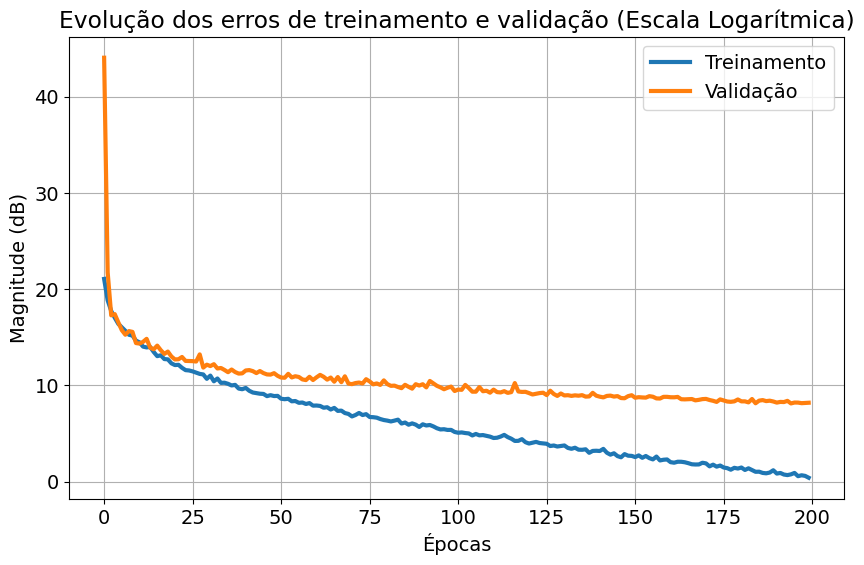

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(20*np.log10(history.history['loss']), linewidth=3)
plt.plot(20*np.log10(history.history['val_loss']), linewidth=3)
plt.title('Evolução dos erros de treinamento e validação (Escala Logarítmica)')
plt.ylabel('Magnitude (dB)')
plt.xlabel('Épocas')
plt.legend(['Treinamento', 'Validação'], loc='upper right')
plt.grid()

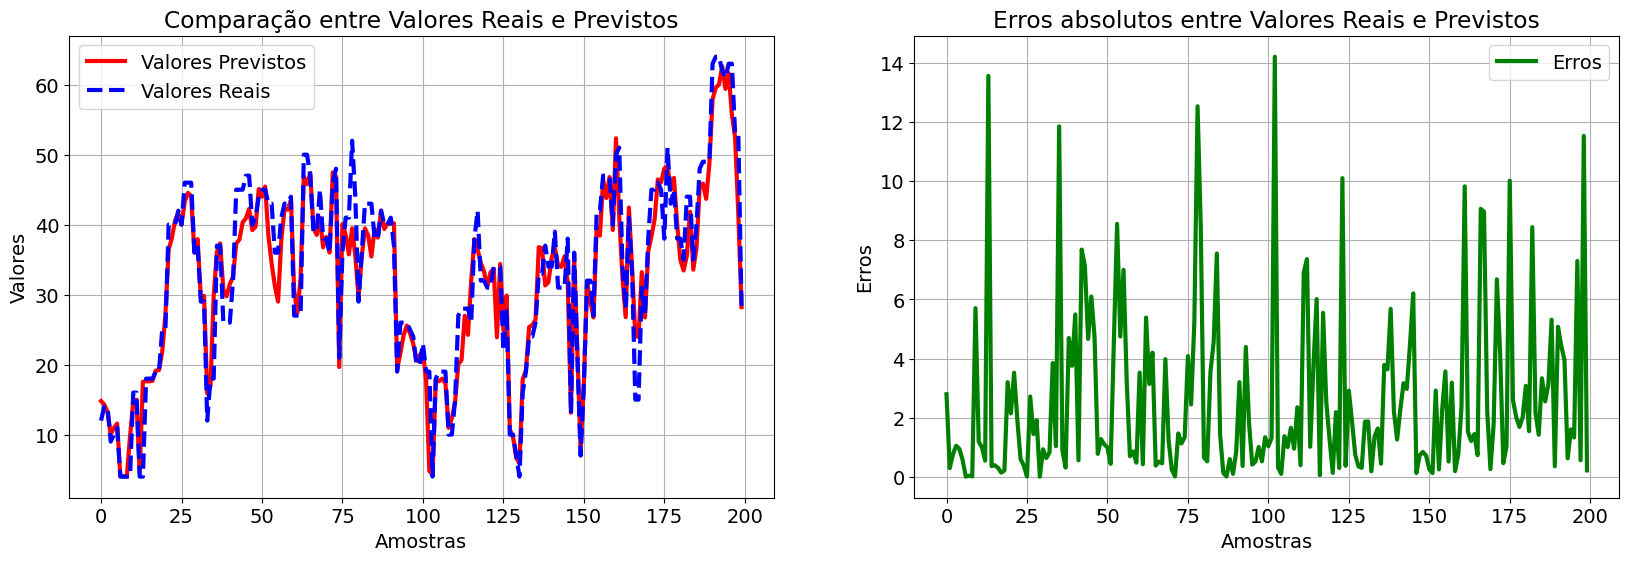

In [29]:
plt.figure(figsize=(20, 6))
plt.subplot(1,2,1)
plt.plot(y_test_pred[:200], 'r-', label='Valores Previstos', linewidth=3)
plt.plot(y_test.values[:200], 'b--', label='Valores Reais', linewidth=3)
plt.title('Comparação entre Valores Reais e Previstos')
plt.xlabel('Amostras')
plt.ylabel('Valores')
plt.grid()
plt.legend()

plt.subplot(1,2,2)
plt.plot(np.abs(y_test.values[:200] - y_test_pred[:200]), label='Erros', color='green', linewidth=3)
plt.title('Erros absolutos entre Valores Reais e Previstos')
plt.xlabel('Amostras')
plt.ylabel('Erros')
plt.grid()
plt.legend()


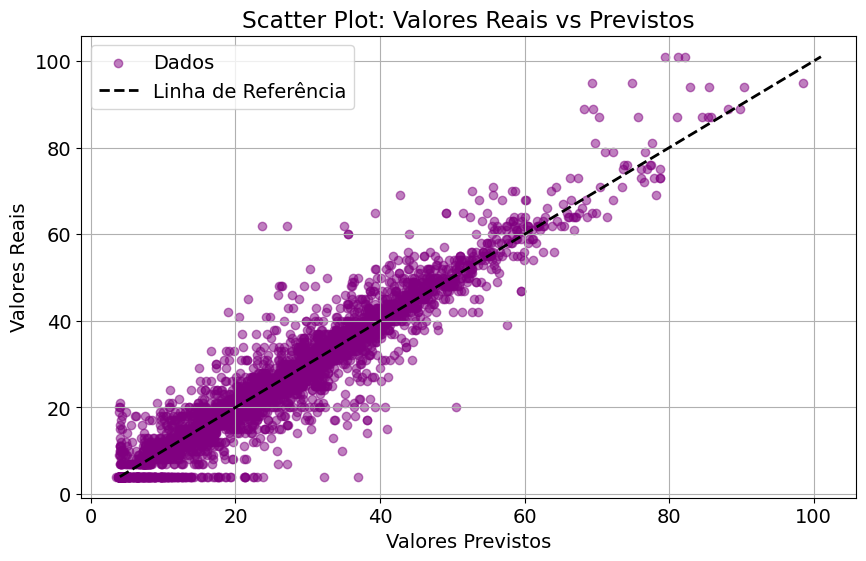

In [28]:
# Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred, y_test.values, color='purple', alpha=0.5, label='Dados')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Linha de Referência')  # Linha de referência y=x
plt.title('Scatter Plot: Valores Reais vs Previstos')
plt.ylabel('Valores Reais')
plt.xlabel('Valores Previstos')
plt.grid()
plt.legend()

In [27]:
# Metricas de erro e R2
mae = mean_absolute_error(y_test.values, y_test_pred)
rmse = root_mean_squared_error(y_test.values, y_test_pred)
r2 = r2_score(y_test.values, y_test_pred)
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')

MAE: 2.5693
RMSE: 4.4303
R2: 0.9213
